# TP2 - Ejercicio 2: Combates Eternos en el Netherrealm
## Que pide y como se resuelve

Simular **concurrentemente** una gran cantidad de torneos independientes de Mortal Kombat, usando N **hilos** (`threading.Thread`), para reducir el tiempo total de procesamiento. Cada hilo simula una porcion de los torneos totales (por ejemplo, 100.000 torneos con 4 hilos = 25.000 por hilo). Los hilos no pueden comunicarse ni sincronizarse entre si; cada uno guarda sus propios resultados (turnos simulados, victorias por luchador, campeonatos por luchador) en una estructura independiente. La unica coordinacion permitida entre el hilo principal y los trabajadores es `join()`.

Cada torneo: se sortean 8 de los 12 luchadores disponibles (misma probabilidad para todos), y juegan un cuadro de eliminacion simple (Cuartos de final -> Semifinal -> Final). Cada combate es por turnos: ataca primero quien tenga mayor velocidad (empate al azar); en cada ataque el defensor puede bloquear (dano 0), y si no bloquea el dano base es `ataque - defensa` (minimo 1 punto), duplicado si es golpe critico. El combate termina cuando un luchador se queda sin vida.

**Como se evita la sincronizacion:** los 12 luchadores tienen atributos fijos (dentro de los rangos de la consigna) para que las corridas sean comparables. El total de torneos se reparte parejo entre los N hilos, y las semillas se generan secuencialmente en el hilo principal ANTES de lanzar ningun hilo (cada uno usa su propio `random.Random(seed)`). Cada hilo escribe sus resultados en su propia posicion de una lista ya reservada, asi que no hace falta ningun lock. La creacion es concurrente: se lanzan todos los hilos en un bucle, y recien despues se espera a cada uno con `join()`.

## Programa

In [1]:
%%writefile mortal_kombat.py

import random
import sys
import threading
import time
from collections import Counter


FIGHTERS = {
    "Liu Kang":    {"life": 100, "attack": 22, "defense": 10, "speed": 7,  "crit": 0.15, "block": 0.15},
    "Kung Lao":    {"life": 90,  "attack": 20, "defense": 8,  "speed": 9,  "crit": 0.20, "block": 0.10},
    "Johnny Cage": {"life": 95,  "attack": 24, "defense": 7,  "speed": 6,  "crit": 0.18, "block": 0.12},
    "Reptile":     {"life": 85,  "attack": 21, "defense": 9,  "speed": 8,  "crit": 0.15, "block": 0.15},
    "Sub-Zero":    {"life": 105, "attack": 19, "defense": 13, "speed": 5,  "crit": 0.10, "block": 0.20},
    "Shang Tsung": {"life": 90,  "attack": 23, "defense": 6,  "speed": 6,  "crit": 0.22, "block": 0.08},
    "Kitana":      {"life": 88,  "attack": 20, "defense": 8,  "speed": 10, "crit": 0.17, "block": 0.13},
    "Jax":         {"life": 120, "attack": 26, "defense": 12, "speed": 3,  "crit": 0.08, "block": 0.10},
    "Mileena":     {"life": 82,  "attack": 25, "defense": 5,  "speed": 9,  "crit": 0.25, "block": 0.05},
    "Baraka":      {"life": 110, "attack": 27, "defense": 11, "speed": 4,  "crit": 0.12, "block": 0.10},
    "Scorpion":    {"life": 100, "attack": 24, "defense": 9,  "speed": 7,  "crit": 0.20, "block": 0.12},
    "Raiden":      {"life": 92,  "attack": 22, "defense": 10, "speed": 8,  "crit": 0.16, "block": 0.18},
}

FIGHTER_NAMES = list(FIGHTERS.keys())
FIGHTERS_PER_TOURNAMENT = 8


def simulate_combat(name_a, name_b, rng):

    hp = {name_a: FIGHTERS[name_a]["life"], name_b: FIGHTERS[name_b]["life"]}

    speed_a = FIGHTERS[name_a]["speed"]
    speed_b = FIGHTERS[name_b]["speed"]
    if speed_a > speed_b:
        attacker, defender = name_a, name_b
    elif speed_b > speed_a:
        attacker, defender = name_b, name_a
    else:
        attacker, defender = (name_a, name_b) if rng.random() < 0.5 else (name_b, name_a)

    turns = 0
    while True:
        turns += 1
        def_stats = FIGHTERS[defender]
        atk_stats = FIGHTERS[attacker]

        if rng.random() < def_stats["block"]:
            damage = 0
        else:
            damage = max(1, atk_stats["attack"] - def_stats["defense"])
            if rng.random() < atk_stats["crit"]:
                damage *= 2

        hp[defender] -= damage
        if hp[defender] <= 0:
            return attacker, turns

        attacker, defender = defender, attacker


def simulate_tournament(rng):

    bracket = rng.sample(FIGHTER_NAMES, FIGHTERS_PER_TOURNAMENT)
    wins = Counter()
    total_turns = 0

    round_fighters = bracket
    while len(round_fighters) > 1:
        next_round = []
        for i in range(0, len(round_fighters), 2):
            winner, turns = simulate_combat(round_fighters[i], round_fighters[i + 1], rng)
            wins[winner] += 1
            total_turns += turns
            next_round.append(winner)
        round_fighters = next_round

    champion = round_fighters[0]
    return champion, total_turns, wins


def worker(seed, tournaments_to_run, result_slot):

    rng = random.Random(seed)
    total_turns = 0
    win_counts = Counter()
    championship_counts = Counter()

    for _ in range(tournaments_to_run):
        champion, turns, wins = simulate_tournament(rng)
        total_turns += turns
        win_counts.update(wins)
        championship_counts[champion] += 1

    result_slot["turns"] = total_turns
    result_slot["wins"] = win_counts
    result_slot["championships"] = championship_counts


def main():
    total_tournaments = int(sys.argv[1]) if len(sys.argv) > 1 else 10000
    num_threads = int(sys.argv[2]) if len(sys.argv) > 2 else 4

    if total_tournaments <= 0 or num_threads <= 0:
        print("Tanto la cantidad de torneos como la de hilos deben ser enteros positivos.")
        sys.exit(1)

    base_share = total_tournaments // num_threads
    remainder = total_tournaments % num_threads
    shares = [base_share + (1 if i < remainder else 0) for i in range(num_threads)]

    seeding_rng = random.Random()
    seeds = [seeding_rng.random() for _ in range(num_threads)]

    results = [dict() for _ in range(num_threads)]
    threads = []

    start = time.perf_counter()

    for i in range(num_threads):
        t = threading.Thread(target=worker, args=(seeds[i], shares[i], results[i]))
        threads.append(t)
        t.start()

    for t in threads:
        t.join()

    elapsed = time.perf_counter() - start

    total_turns = sum(r["turns"] for r in results)
    total_wins = Counter()
    total_championships = Counter()
    for r in results:
        total_wins.update(r["wins"])
        total_championships.update(r["championships"])

    print(f"Torneos simulados: {total_tournaments}")
    print(f"Hilos usados: {num_threads}")
    print(f"Turnos de combate totales: {total_turns}")
    print("Victorias por luchador:")
    for name in FIGHTER_NAMES:
        print(f"  {name}: {total_wins.get(name, 0)}")
    print("Campeonatos por luchador:")
    for name in FIGHTER_NAMES:
        print(f"  {name}: {total_championships.get(name, 0)}")
    print(f"Tiempo total: {elapsed * 1000:.1f} ms")


if __name__ == "__main__":
    main()


Writing mortal_kombat.py


## Ejecutar una vez, para ver el resultado

In [2]:
!python3 mortal_kombat.py 5000 4

Torneos simulados: 5000
Hilos usados: 4
Turnos de combate totales: 456227
Victorias por luchador:
  Liu Kang: 3213
  Kung Lao: 683
  Johnny Cage: 1781
  Reptile: 1137
  Sub-Zero: 3144
  Shang Tsung: 720
  Kitana: 886
  Jax: 7657
  Mileena: 1009
  Baraka: 8072
  Scorpion: 3579
  Raiden: 3119
Campeonatos por luchador:
  Liu Kang: 187
  Kung Lao: 2
  Johnny Cage: 37
  Reptile: 7
  Sub-Zero: 120
  Shang Tsung: 1
  Kitana: 1
  Jax: 1886
  Mileena: 2
  Baraka: 2280
  Scorpion: 289
  Raiden: 188
Tiempo total: 667.7 ms


## Tiempo vs. cantidad de hilos

Se corre el script para distintas cantidades de hilos, con la cantidad de torneos FIJA, se repite cada configuracion unas cuantas veces y se promedia el tiempo.

hilos=1: tiempos=[4128, 3063, 1381] ms -> promedio=2857.3 ms
hilos=2: tiempos=[1325, 1317, 1324] ms -> promedio=1322.0 ms
hilos=4: tiempos=[2535, 1767, 1336] ms -> promedio=1879.2 ms
hilos=8: tiempos=[1348, 1360, 1343] ms -> promedio=1350.5 ms
hilos=16: tiempos=[1352, 1389, 2015] ms -> promedio=1585.1 ms


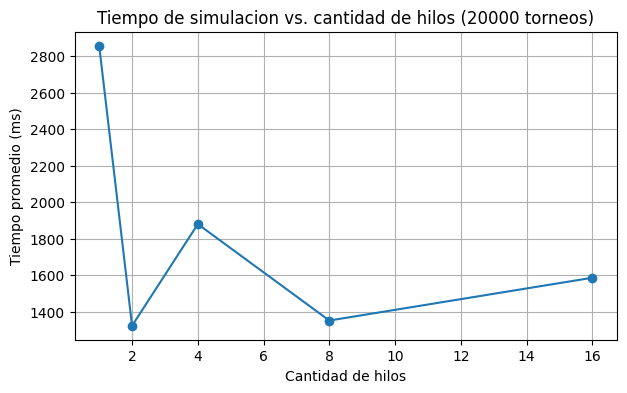

Menor tiempo promedio: 2 hilos (1322.0 ms)


In [3]:
import subprocess
import re
import matplotlib.pyplot as plt

TOTAL_TOURNAMENTS = 20000
thread_counts = [1, 2, 4, 8, 16]
repeats = 3
avg_times = []

for n in thread_counts:
    times = []
    for _ in range(repeats):
        out = subprocess.run(
            ["python3", "mortal_kombat.py", str(TOTAL_TOURNAMENTS), str(n)],
            capture_output=True, text=True,
        ).stdout
        m = re.search(r"Tiempo total: ([\d.]+) ms", out)
        times.append(float(m.group(1)))
    avg = sum(times) / len(times)
    avg_times.append(avg)
    print(f"hilos={n}: tiempos={[round(t) for t in times]} ms -> promedio={avg:.1f} ms")

plt.figure(figsize=(7, 4))
plt.plot(thread_counts, avg_times, marker="o")
plt.xlabel("Cantidad de hilos")
plt.ylabel("Tiempo promedio (ms)")
plt.title(f"Tiempo de simulacion vs. cantidad de hilos ({TOTAL_TOURNAMENTS} torneos)")
plt.grid(True)
plt.show()

best_i = min(range(len(thread_counts)), key=lambda i: avg_times[i])
print(f"Menor tiempo promedio: {thread_counts[best_i]} hilos ({avg_times[best_i]:.1f} ms)")

## Analisis

1. **Hilos vs. tiempo:** el grafico de arriba muestra la relacion entre cantidad de hilos y tiempo promedio para una cantidad fija de torneos.
2. **Cantidad optima:** la celda anterior imprime que cantidad de hilos dio el menor tiempo promedio en esta corrida.
3. **Aumentar hilos indefinidamente no mejora el rendimiento:** a diferencia del ejercicio de C++ (donde los hilos corren en paralelo real sobre varios nucleos), en Python CPython tiene el Global Interpreter Lock (GIL), que permite que solo un hilo ejecute bytecode Python a la vez sin importar la cantidad de nucleos disponibles. Por eso el tiempo de este ejercicio no deberia bajar de forma proporcional a la cantidad de hilos (para trabajo de CPU como es simular combates), y pasada cierta cantidad puede incluso empeorar un poco por el overhead de crear y coordinar hilos, en vez de seguir mejorando como en C++.